# 04 - Retrieval Methods: Strategy Comparison

**Phase 4** of the RAG project. We compare 5 retrieval strategies on the same corpus
to identify the best approach depending on the query type:

1. **Similarity Search** (dense) - baseline cosine similarity
2. **MMR** (Maximum Marginal Relevance) - balances relevance and diversity
3. **BM25** (sparse) - keyword-based search, TF-IDF variant
4. **Hybrid** (Ensemble) - combines dense + sparse via RRF
5. **Multi-Query** - the LLM reformulates the question, results are merged

We use **mxbai-embed-large** (1024d, best semantic separation from Phase 3) and
**recursive** chunking (1000 chars, overlap 200) from Phase 2.
The corpus is filtered to core docs only (~130 pages, ~2200 chunks) - integration
reference pages are excluded as they add noise without relevant content.

### Evaluated Metrics

- **Precision@k** - fraction of top-k results that are relevant
- **Recall@k** - fraction of relevant docs found in the top-k
- **MRR** - reciprocal rank of the first relevant result
- **nDCG@k** - ranking quality (accounts for position)
- **Latency** - retrieval time (ms)
- **Diversity** - average cosine distance between results

---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.retrieval.dense import retrieve_dense, create_dense_retriever, RetrievalStrategyResult
from src.retrieval.sparse import create_bm25_retriever, retrieve_bm25
from src.retrieval.hybrid import create_hybrid_retriever, retrieve_hybrid
from src.retrieval.factory import create_retriever_from_config
from notebooks.utils.display import (
    display_retrieval_results,
    display_strategy_comparison,
    display_category_breakdown,
    display_latency_comparison,
    display_radar_chart,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
    BenchmarkQuestion,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\Astyan\rag-exploration


## 1. Corpus Preparation and Indexing

We load the corpus, **filter out integration reference pages** (90% of the docs are
provider-specific integration pages that add noise to retrieval), then chunk with
the recursive strategy (Phase 2) and index into ChromaDB with nomic-embed-text (Phase 3).
We also build the BM25 index in memory.

In [2]:
# Load and clean
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter out /python/integrations/ pages (90% of the corpus, mostly noise).
# Keep: concepts, guides, langgraph, deepagents, top-level integrations (splitters, etc.)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core (filtered)")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Corpus: 1463 docs -> 1445 cleaned -> 130 core (filtered)
Chunked: 130 docs -> 2217 chunks


In [3]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION = "retrieval_eval_mxbai"
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")  # warmup
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

# ChromaDB index
client = chromadb.PersistentClient(path=PERSIST_DIR)
try:
    client.delete_collection(COLLECTION)
except Exception:
    pass

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
start = time.perf_counter()
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION,
)
index_time = time.perf_counter() - start
print(f"Indexed in {index_time:.1f}s ({vectorstore._collection.count()} chunks)")

# BM25 index
print("Building BM25 index...")
start = time.perf_counter()
bm25_retriever = create_bm25_retriever(chunks, k=5)
bm25_time = time.perf_counter() - start
print(f"BM25 index built in {bm25_time:.1f}s")

Embedding model: mxbai-embed-large (1024d)
Indexing 2217 chunks into ChromaDB...
Indexed in 54.7s (2217 chunks)
Building BM25 index...
BM25 index built in 0.1s


In [4]:
# Load benchmark questions
questions = load_benchmark_questions(str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json"))

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    print(f"  {cat}: {len(qs)} questions")

Benchmark: 25 questions
  conceptual: 6 questions
  error_related: 6 questions
  how_to: 7 questions
  technical: 6 questions


---
## 2. Dense Similarity Search (baseline)

The simplest strategy: encode the query, find the k nearest neighbors
by cosine distance in ChromaDB.

In [5]:
K = 5

dense_metrics = []
for q in questions:
    result = retrieve_dense(vectorstore, q.query, search_type="similarity", k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "similarity"
    dense_metrics.append(m)

dense_df = pd.DataFrame(dense_metrics)
print("Similarity Search - average metrics:")
print(f"  Precision@{K}: {dense_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {dense_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {dense_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {dense_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {dense_df['latency_ms'].mean():.1f} ms")

Similarity Search - average metrics:
  Precision@5: 0.3520
  Recall@5:    0.6533
  MRR:           0.5967
  nDCG@5:      0.6497
  Latency:       51.4 ms


In [6]:
# Example results for a query
example_q = questions[0]
example_result = retrieve_dense(vectorstore, example_q.query, search_type="similarity", k=K)
print(f"Example: '{example_q.query}'")
print(f"  Results: {example_result.num_results}, Latency: {example_result.elapsed_ms:.1f} ms")
display_retrieval_results(
    example_q.query,
    list(zip(example_result.docs, example_result.scores)),
)

Example: 'What is RAG and how does it work?'
  Results: 5, Latency: 26.6 ms


---
## 3. Maximum Marginal Relevance (MMR)

MMR balances relevance and diversity. The `lambda_mult` parameter controls the
trade-off: 1.0 = pure relevance, 0.0 = maximum diversity.

We test 4 values: 0.3, 0.5, 0.7, 0.9.

In [7]:
LAMBDA_VALUES = [0.3, 0.5, 0.7, 0.9]

mmr_all_metrics = []

for lam in LAMBDA_VALUES:
    strategy_name = f"mmr_{lam}"
    print(f"\nMMR lambda={lam}:")
    for q in questions:
        result = retrieve_dense(
            vectorstore, q.query,
            search_type="mmr", k=K, fetch_k=20, lambda_mult=lam,
        )
        m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
        m["strategy"] = strategy_name
        mmr_all_metrics.append(m)

    lam_df = pd.DataFrame([m for m in mmr_all_metrics if m["strategy"] == strategy_name])
    print(f"  Precision@{K}: {lam_df['precision_at_k'].mean():.4f}")
    print(f"  MRR:           {lam_df['mrr'].mean():.4f}")
    print(f"  Latency:       {lam_df['latency_ms'].mean():.1f} ms")

mmr_df = pd.DataFrame(mmr_all_metrics)


MMR lambda=0.3:
  Precision@5: 0.2240
  MRR:           0.5267
  Latency:       59.8 ms

MMR lambda=0.5:
  Precision@5: 0.2560
  MRR:           0.5733
  Latency:       62.4 ms

MMR lambda=0.7:
  Precision@5: 0.3120
  MRR:           0.5980
  Latency:       61.2 ms

MMR lambda=0.9:
  Precision@5: 0.3680
  MRR:           0.6047
  Latency:       75.6 ms


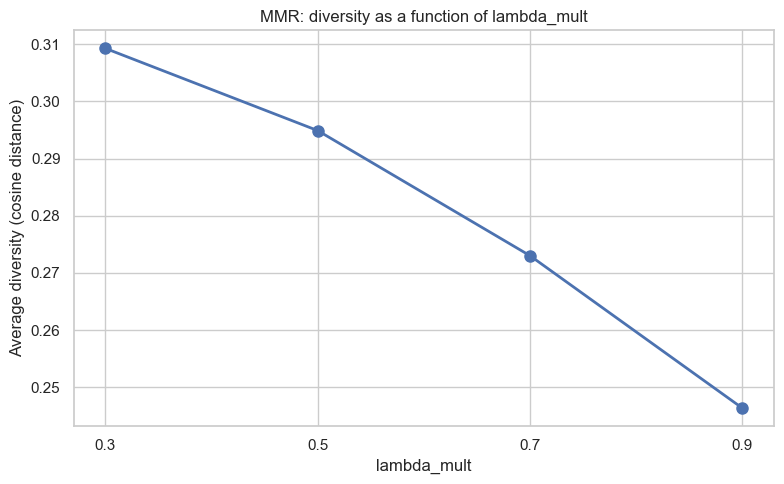


Average diversity by lambda:


,avg_diversity
lambda,
0.3,0.3093
0.5,0.2949
0.7,0.2730
0.9,0.2464


In [8]:
# Diversity vs relevance comparison by lambda
from notebooks.utils.metrics import diversity_score

diversity_data = []

# Pick 3 representative queries for diversity analysis
sample_queries = [questions[0], questions[6], questions[12]]

for lam in LAMBDA_VALUES:
    for q in sample_queries:
        result = retrieve_dense(
            vectorstore, q.query,
            search_type="mmr", k=K, fetch_k=20, lambda_mult=lam,
        )
        div = diversity_score(result.docs, embeddings)
        diversity_data.append({
            "lambda": lam,
            "query": q.query[:50],
            "diversity": round(div, 4),
        })

div_df = pd.DataFrame(diversity_data)
div_summary = div_df.groupby("lambda")["diversity"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(div_summary.index, div_summary.values, "o-", linewidth=2, markersize=8)
ax.set_xlabel("lambda_mult")
ax.set_ylabel("Average diversity (cosine distance)")
ax.set_title("MMR: diversity as a function of lambda_mult")
ax.set_xticks(LAMBDA_VALUES)
plt.tight_layout()
plt.show()

print("\nAverage diversity by lambda:")
display(div_summary.to_frame("avg_diversity").round(4))

---
## 4. Sparse BM25 Search

BM25 is a keyword-based method (TF-IDF variant).
It excels when the query contains specific terms
(class names, functions, error messages).

In [9]:
bm25_metrics = []
for q in questions:
    result = retrieve_bm25(bm25_retriever, q.query)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "bm25"
    bm25_metrics.append(m)

bm25_df = pd.DataFrame(bm25_metrics)
print("BM25 - average metrics:")
print(f"  Precision@{K}: {bm25_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {bm25_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {bm25_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {bm25_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {bm25_df['latency_ms'].mean():.1f} ms")

BM25 - average metrics:
  Precision@5: 0.1440
  Recall@5:    0.2933
  MRR:           0.3027
  nDCG@5:      0.2770
  Latency:       2.3 ms


In [10]:
# BM25 shines on technical queries
tech_q = [q for q in questions if q.category == "technical"][0]
bm25_result = retrieve_bm25(bm25_retriever, tech_q.query)
dense_result = retrieve_dense(vectorstore, tech_q.query, search_type="similarity", k=K)

print(f"Technical query: '{tech_q.query}'")
print(f"\n--- BM25 ---")
for i, doc in enumerate(bm25_result.docs[:3], 1):
    title = doc.metadata.get("title", "?")[:60]
    print(f"  {i}. {title}")

print(f"\n--- Dense ---")
for i, doc in enumerate(dense_result.docs[:3], 1):
    title = doc.metadata.get("title", "?")[:60]
    print(f"  {i}. {title} (score: {dense_result.scores[i-1]:.4f})")

Technical query: 'What parameters does RecursiveCharacterTextSplitter accept?'

--- BM25 ---
  1. Context engineering in agents
  2. Functional API overview
  3. Build a custom RAG agent with LangGraph

--- Dense ---
  1. Splitting recursively - Text splitter integration guide (score: 0.4184)
  2. Splitting code text splitter integration guide (score: 0.4222)
  3. Splitting recursively - Text splitter integration guide (score: 0.4476)


---
## 5. Hybrid Search (Ensemble)

The EnsembleRetriever combines results from multiple retrievers
via Reciprocal Rank Fusion (RRF). We test 3 weight configurations
\[dense, sparse\]:

- **0.7/0.3** - favors semantic similarity
- **0.5/0.5** - equal weights
- **0.3/0.7** - favors keywords

In [11]:
WEIGHT_CONFIGS = [
    ([0.7, 0.3], "0.7/0.3"),
    ([0.5, 0.5], "0.5/0.5"),
    ([0.3, 0.7], "0.3/0.7"),
]

dense_ret = create_dense_retriever(vectorstore, search_type="similarity", k=10)

hybrid_all_metrics = []

for weights, label in WEIGHT_CONFIGS:
    bm25_ret = create_bm25_retriever(chunks, k=10)
    hybrid_ret = create_hybrid_retriever(dense_ret, bm25_ret, weights=weights)
    strategy_name = f"hybrid_{label}"
    print(f"\nHybrid [{label}]:")

    for q in questions:
        result = retrieve_hybrid(hybrid_ret, q.query, weights_label=label)
        # Limit to K results
        result_docs = result.docs[:K]
        m = compute_retrieval_metrics(result_docs, q, result.elapsed_ms, k=K)
        m["strategy"] = strategy_name
        hybrid_all_metrics.append(m)

    lbl_df = pd.DataFrame([m for m in hybrid_all_metrics if m["strategy"] == strategy_name])
    print(f"  Precision@{K}: {lbl_df['precision_at_k'].mean():.4f}")
    print(f"  MRR:           {lbl_df['mrr'].mean():.4f}")
    print(f"  Latency:       {lbl_df['latency_ms'].mean():.1f} ms")

hybrid_df = pd.DataFrame(hybrid_all_metrics)


Hybrid [0.7/0.3]:
  Precision@5: 0.3440
  MRR:           0.5100
  Latency:       34.6 ms

Hybrid [0.5/0.5]:
  Precision@5: 0.2720
  MRR:           0.5447
  Latency:       34.8 ms

Hybrid [0.3/0.7]:
  Precision@5: 0.1760
  MRR:           0.4333
  Latency:       36.2 ms


---
## 6. Multi-Query Retriever

The LLM (Mistral 7B via Ollama) generates N reformulations of the question.
Each variant retrieves documents, then results are merged and deduplicated.

> **Note**: this strategy is slower because each query requires
> an LLM call (~2-5 seconds per reformulation).

In [12]:
from langchain_ollama import ChatOllama
from langchain_classic.retrievers.multi_query import MultiQueryRetriever

llm = ChatOllama(model="mistral:7b", temperature=0.3)

base_retriever = create_dense_retriever(vectorstore, search_type="similarity", k=K)
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=base_retriever,
    llm=llm,
)

print(f"Multi-Query Retriever: base=similarity(k={K}), LLM=mistral:7b")
print(f"Benchmarking on {len(questions)} questions (may take a few minutes)...\n")

mq_metrics = []
for i, q in enumerate(questions):
    start = time.perf_counter()
    try:
        docs = multi_query_retriever.invoke(q.query)
    except Exception as e:
        print(f"  [{q.id}] Error: {e}")
        docs = []
    elapsed_ms = (time.perf_counter() - start) * 1000

    docs = docs[:K]  # limit to K
    m = compute_retrieval_metrics(docs, q, elapsed_ms, k=K)
    m["strategy"] = "multi_query"
    mq_metrics.append(m)

    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(questions)} questions processed...")

mq_df = pd.DataFrame(mq_metrics)
print(f"\nMulti-Query - average metrics:")
print(f"  Precision@{K}: {mq_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {mq_df['mrr'].mean():.4f}")
print(f"  Latency:       {mq_df['latency_ms'].mean():.1f} ms")

Multi-Query Retriever: base=similarity(k=5), LLM=mistral:7b
Benchmarking on 25 questions (may take a few minutes)...

  5/25 questions processed...
  10/25 questions processed...
  15/25 questions processed...
  20/25 questions processed...
  25/25 questions processed...

Multi-Query - average metrics:
  Precision@5: 0.3440
  MRR:           0.5080
  Latency:       5019.3 ms


---
## 7. Global Comparison

Aggregated metrics across all strategies.

In [13]:
# Combine all results
all_metrics_df = pd.concat([dense_df, mmr_df, bm25_df, hybrid_df, mq_df], ignore_index=True)

# Aggregate per strategy
summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=('precision_at_k', 'mean'),
        avg_recall=('recall_at_k', 'mean'),
        avg_mrr=('mrr', 'mean'),
        avg_ndcg=('ndcg_at_k', 'mean'),
        avg_latency_ms=('latency_ms', 'mean'),
    )
    .round(4)
)

print("Global comparison of retrieval strategies:")
display_strategy_comparison(summary.reset_index())

Global comparison of retrieval strategies:


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms
0,bm25,0.144000,0.293300,0.302700,0.277000,2.3
1,hybrid_0.3/0.7,0.176000,0.320000,0.433300,0.368300,36.2
2,hybrid_0.5/0.5,0.272000,0.566700,0.544700,0.538900,34.8
3,hybrid_0.7/0.3,0.344000,0.626700,0.510000,0.605700,34.6
4,mmr_0.3,0.224000,0.466700,0.526700,0.461000,59.8
5,mmr_0.5,0.256000,0.520000,0.573300,0.510100,62.4
6,mmr_0.7,0.312000,0.626700,0.598000,0.606800,61.2
7,mmr_0.9,0.368000,0.673300,0.604700,0.669700,75.6
8,multi_query,0.344000,0.566700,0.508000,0.571200,5019.3
9,similarity,0.352000,0.653300,0.596700,0.649700,51.4


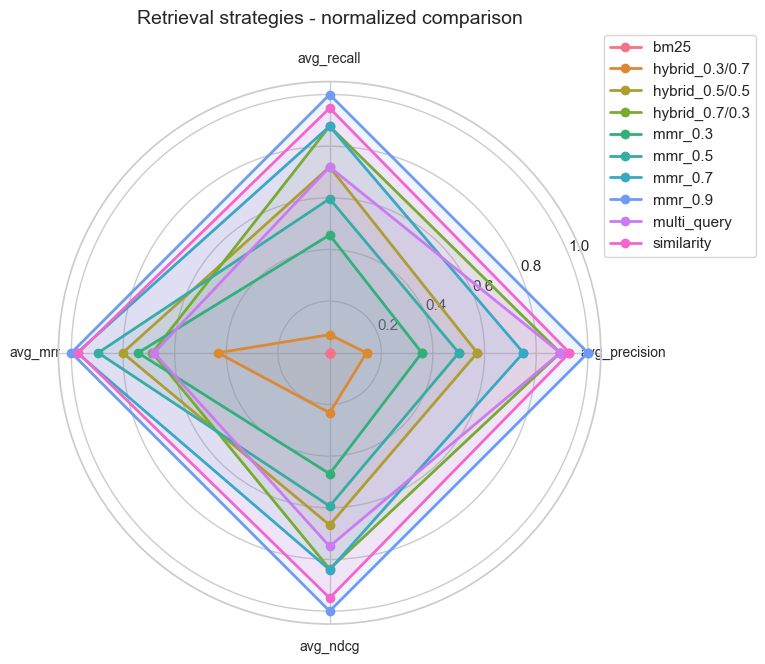

In [14]:
# Radar chart (normalized metrics, excluding latency)
radar_df = summary.reset_index().copy()

# Normalize each metric to [0, 1]
radar_metrics = ["avg_precision", "avg_recall", "avg_mrr", "avg_ndcg"]
radar_norm = radar_df.copy()
for col in radar_metrics:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    if col_max > col_min:
        radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min)
    else:
        radar_norm[col] = 0.5

display_radar_chart(
    radar_norm,
    metrics=radar_metrics,
    strategy_col="strategy",
    title="Retrieval strategies - normalized comparison",
)

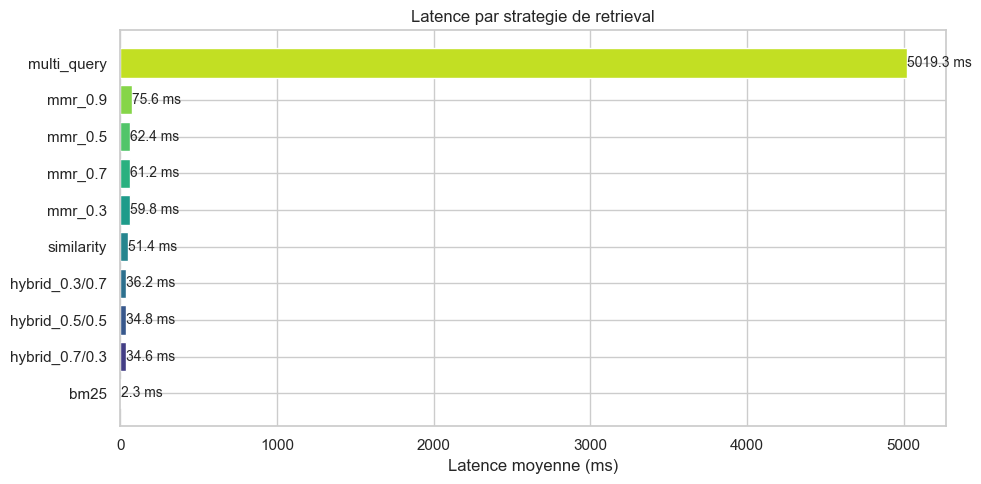

In [15]:
# Latency comparison
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

---
## 8. Analysis by Query Type

Not all strategies perform equally well for each question type.
We analyze performance by category:

- **conceptual**: "What is RAG?" - dense likely best
- **technical**: "What parameters does RecursiveCharacterTextSplitter take?" - BM25 likely best
- **how_to**: "How to create a chatbot?" - hybrid likely best
- **error_related**: "What does MODEL_NOT_FOUND mean?" - BM25 likely best

In [16]:
# Per-category breakdown
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(
        avg_precision=('precision_at_k', 'mean'),
        avg_mrr=('mrr', 'mean'),
        avg_latency_ms=('latency_ms', 'mean'),
    )
    .round(4)
    .reset_index()
)

# Best strategy per category
print("Best strategy per category (Precision@k):")
best_per_cat = cat_summary.loc[
    cat_summary.groupby("category")["avg_precision"].idxmax()
][["category", "strategy", "avg_precision"]]
display(best_per_cat.set_index("category"))

print("\nBest strategy per category (MRR):")
best_mrr = cat_summary.loc[
    cat_summary.groupby("category")["avg_mrr"].idxmax()
][["category", "strategy", "avg_mrr"]]
display(best_mrr.set_index("category"))

Best strategy per category (Precision@k):


,strategy,avg_precision
category,,
conceptual,mmr_0.9,0.7333
error_related,mmr_0.7,0.2667
how_to,multi_query,0.3429
technical,multi_query,0.2667



Best strategy per category (MRR):


,strategy,avg_mrr
category,,
conceptual,mmr_0.5,0.9167
error_related,mmr_0.7,0.7083
how_to,multi_query,0.5524
technical,hybrid_0.5/0.5,0.3889


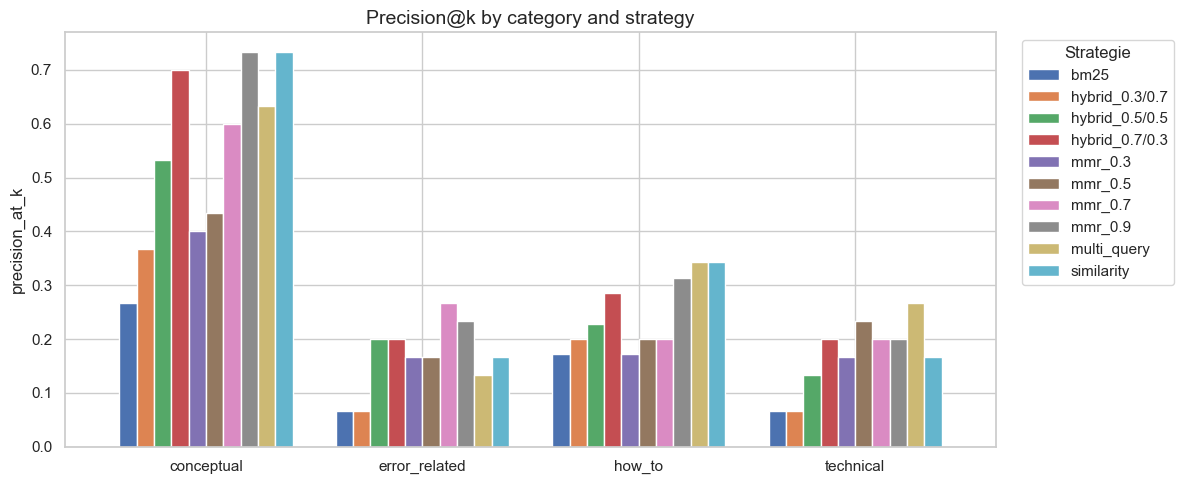

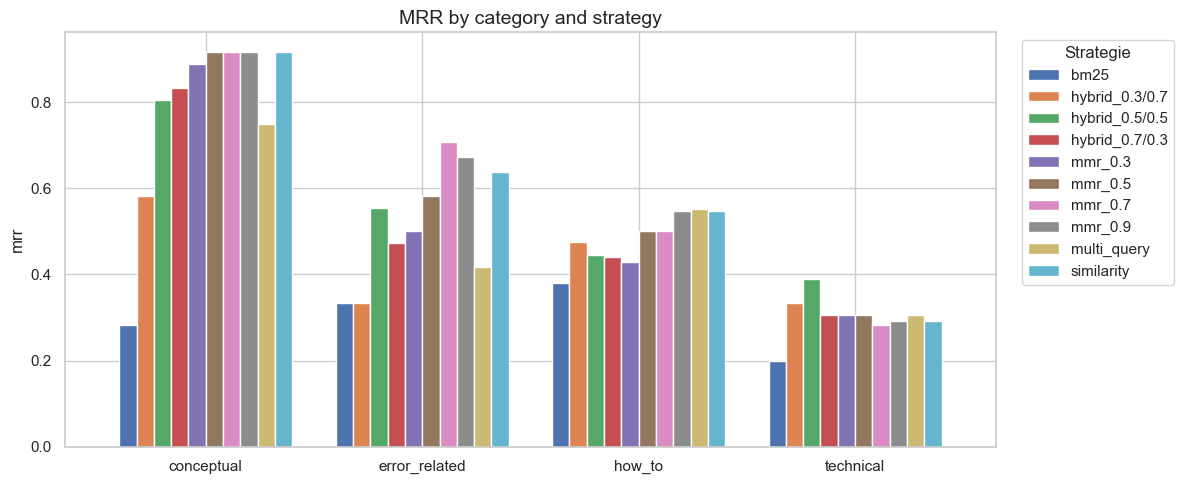

In [17]:
display_category_breakdown(
    all_metrics_df, metric="precision_at_k",
    title="Precision@k by category and strategy",
)

display_category_breakdown(
    all_metrics_df, metric="mrr",
    title="MRR by category and strategy",
)

---
## 9. Save Results

In [18]:
# Build results output
results_output = {
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "strategies": {},
    "best_per_category": {},
    "benchmark_queries": [q.query for q in questions],
}

# Per-strategy aggregates
for strategy_name, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["strategies"][strategy_name] = entry

# Best per category
for cat in sorted(categories.keys()):
    cat_data = cat_summary[cat_summary["category"] == cat]
    best = cat_data.loc[cat_data["avg_precision"].idxmax()]
    results_output["best_per_category"][cat] = best["strategy"]

# Save
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "retrieval_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to D:\Astyan\rag-exploration\results\retrieval_comparison.json


---
## 10. Cleanup

In [19]:
# Clean up evaluation collection
try:
    client.delete_collection(COLLECTION)
    print(f"Collection '{COLLECTION}' deleted.")
except Exception:
    pass

# Also clean up stale nomic collection from previous runs
try:
    client.delete_collection("retrieval_eval_nomic")
    print("Deleted stale 'retrieval_eval_nomic' collection.")
except Exception:
    pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Collection 'retrieval_eval_mxbai' deleted.
Deleted stale 'retrieval_eval_nomic' collection.
Remaining collections: ['sensitivity_cs750', 'sensitivity_cs1500', 'sensitivity_cs2000', 'sensitivity_cs1000', 'langchain_docs_naive', 'chunking_eval_recursive', 'chunking_eval_fixed', 'chunking_eval_markdown', 'chunking_eval_token', 'sensitivity_cs500']


---
## 11. Summary & Observations

### Corpus Filtering

The raw corpus contains 1463 pages, but 90% are provider-specific integration
reference pages (e.g. "Pinecone integration", "OpenAI chat model") that add
noise without contributing relevant content. We filtered down to 130 core pages
(concepts, guides, LangGraph, error docs) before indexing (2217 chunks).

### Results

| Strategy | Precision@5 | MRR | nDCG@5 | Latency | Notes |
|---|---|---|---|---|---|
| Similarity | 0.352 | 0.597 | 0.650 | 51 ms | Strong baseline |
| MMR (lambda=0.9) | **0.368** | **0.605** | **0.670** | 76 ms | Best overall |
| MMR (lambda=0.7) | 0.312 | 0.598 | 0.607 | 61 ms | Good balance |
| BM25 | 0.144 | 0.303 | 0.277 | **2 ms** | Fastest, weakest |
| Hybrid (0.7/0.3) | 0.344 | 0.510 | 0.606 | 35 ms | Good precision |
| Hybrid (0.5/0.5) | 0.272 | 0.545 | 0.539 | 35 ms | Balanced |
| Multi-Query | 0.344 | 0.508 | 0.571 | 5019 ms | 100x slower, no gain |

### Best Strategy by Query Type

| Category | Best (Precision) | Best (MRR) | Note |
|---|---|---|---|
| conceptual | mmr_0.9 (0.733) | mmr_0.5 (0.917) | Dense clearly wins |
| error_related | mmr_0.7 (0.267) | mmr_0.7 (0.708) | Semantic > keyword |
| how_to | multi_query (0.343) | multi_query (0.552) | Marginal advantage |
| technical | multi_query (0.267) | hybrid_0.5/0.5 (0.389) | Dense competitive |

### Key Takeaways

1. **MMR (lambda=0.9) is the best overall strategy** - it slightly edges out plain
   similarity by penalizing duplicate chunks, while staying near-relevance-only behavior.

2. **Dense similarity is an excellent baseline** - nearly ties MMR at 2/3 the latency.
   For a production system with tight latency requirements, this is the pragmatic choice.

3. **BM25 alone is insufficient** - MRR of 0.30 vs 0.60 for dense. Pure keyword matching
   fails on conceptual and semantic queries. But at 2 ms it has a role in hybrid systems.

4. **Hybrid search does not outperform dense on this corpus** - with mxbai-embed-large
   producing good semantic representations, adding BM25 at 30% weight (hybrid_0.7/0.3)
   matches similarity precision but hurts MRR (0.510 vs 0.597).

5. **Multi-Query is not worth the cost** - 100x slower than similarity (5 seconds vs 51 ms)
   with no improvement in overall metrics. Mistral 7B generates useful reformulations
   for how_to queries but adds noise elsewhere.

6. **Conceptual queries are well-served by dense search** - MRR of 0.917 on conceptual
   category with MMR/similarity. Semantic embeddings capture meaning effectively.

7. **Technical queries remain the hardest category** - best MRR is only 0.389
   (hybrid_0.5/0.5). Exact class/function names are short and ambiguous without context.

### Evaluation Limitations

- Relevance annotations use partial URL matching on source metadata.
  This is an approximation - some chunks from a "relevant" page may not
  actually answer the question, inflating recall but not precision.
- Full end-to-end evaluation with generated answers comes in Phase 9 (RAGAS)
  with manually annotated question-answer pairs.
- BM25 and Hybrid return no scores, so score-based metrics are not comparable.
  We focus on rank-based metrics (MRR, nDCG).

### Recommendation

**Use MMR (lambda=0.9) as the default retriever** going forward - it delivers the best
MRR (0.605) and nDCG (0.670) with moderate latency (76 ms). For latency-sensitive
scenarios, plain similarity (MRR: 0.597, 51 ms) is equivalent.

### Next Step: Phase 5 - Query Translation

We will explore query reformulation techniques (HyDE, RAG Fusion, Step-Back,
Decomposition) to improve retrieval upstream, particularly for technical queries
where all strategies currently plateau below MRR 0.40.